##Actividad 8

### Preparación de Entorno y Datos
Importaremos las librerías base y prepararemos el dataset MNIST para el entrenamiento.

Cargaremos el dataset MNIST, normalizaremos los tensores a un rango [0, 1] y crearemos los conjuntos de datos.

Mostramos las primeras 5 imágenes para confirmar la carga.

TensorFlow version: 2.19.0
Imágenes de entrenamiento: (48000, 28, 28)
Imágenes de validación: (12000, 28, 28)
Imágenes de prueba: (10000, 28, 28)


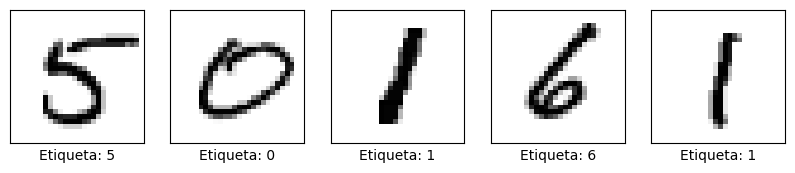

In [21]:
import numpy as np # Importa librería para manejo de arreglos numéricos
import matplotlib.pyplot as plt # Importa librería para visualización de datos
import tensorflow as tf # Importa el framework de Deep Learning
from tensorflow.keras import datasets, layers, models # Importa herramientas específicas de Keras
from sklearn.model_selection import train_test_split # Importa función para dividir el dataset

print("TensorFlow version:", tf.__version__) # Imprime la versión activa de TensorFlow

# Cargar dataset MNIST (dígitos escritos a mano)
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

# Normalización de valores de píxeles (convierte rango 0-255 a 0.0-1.0 para mejor convergencia)
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# Partición para validación (separa 20% de los datos de entrenamiento para monitoreo)
train_images, val_images, train_labels, val_labels = train_test_split(
    train_images, train_labels, test_size=0.2, random_state=42
)

print(f"Imágenes de entrenamiento: {train_images.shape}") # Muestra cantidad y tamaño de entrenamiento
print(f"Imágenes de validación: {val_images.shape}") # Muestra cantidad y tamaño de validación
print(f"Imágenes de prueba: {test_images.shape}") # Muestra cantidad y tamaño de prueba

plt.figure(figsize=(10, 2)) # Define el tamaño de la figura
for i in range(5): # Itera para mostrar los primeros 5 ejemplos
    plt.subplot(1, 5, i+1) # Crea una sub-grilla de 1x5
    plt.xticks([]) # Elimina marcas en el eje X
    plt.yticks([]) # Elimina marcas en el eje Y
    plt.grid(False) # Desactiva la cuadrícula
    plt.imshow(train_images[i], cmap=plt.cm.binary) # Muestra imagen en blanco y negro
    plt.xlabel(f"Etiqueta: {train_labels[i]}") # Coloca la clase real como etiqueta
plt.show() # Despliega la gráfica

### Arquitectura Base de la Red Neuronal

Definiremos una red neuronal convolucional (CNN) con la siguiente configuración:
1. **Capas Convolucionales**: Para extraer características espaciales.
2. **Capas de Pooling**: Para reducir la dimensionalidad.
3. **Capas Densas**: Para la clasificación final en 10 categorías (dígitos del 0 al 9).

Configuraremos el modelo para el entrenamiento definiendo:
- **Optimizador**: Adam (ajusta los pesos eficientemente).
- **Loss Function**: Sparse Categorical Crossentropy (ideal para etiquetas enteras como en MNIST).
- **Métricas**: Accuracy (precisión de clasificación).

In [22]:
def build_base_model():
    model = models.Sequential([ # Inicia definición de modelo secuencial (capa tras capa)
        # Definir la entrada de forma explícita (28x28 píxeles, 1 canal de color)
        layers.Input(shape=(28, 28, 1)),

        # Primera capa convolucional: 32 filtros de 3x3 para detectar rasgos simples
        layers.Conv2D(32, (3, 3), activation='relu'),
        # Capa de pooling: reduce tamaño a la mitad tomando el valor máximo
        layers.MaxPooling2D((2, 2)),

        # Segunda capa convolucional: 64 filtros para detectar rasgos complejos
        layers.Conv2D(64, (3, 3), activation='relu'),
        # Segunda capa de pooling
        layers.MaxPooling2D((2, 2)),

        # Aplanar: convierte la matriz 2D en un vector unidimensional
        layers.Flatten(),
        # Capa densa (oculta): 64 neuronas para procesar características
        layers.Dense(64, activation='relu'),

        # Capa de salida: 10 neuronas (una por dígito) con Softmax para probabilidades
        layers.Dense(10, activation='softmax')
    ])

    return model # Retorna el objeto del modelo

# Instanciar el modelo
base_model = build_base_model()

# Resumen de la arquitectura (muestra capas y parámetros)
base_model.summary()

base_model.compile(
    optimizer='adam', # Algoritmo de optimización eficiente
    loss='sparse_categorical_crossentropy', # Función de error para etiquetas enteras
    metrics=['accuracy'] # Métrica de desempeño: precisión
)

print("Modelo compilado exitosamente.")

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Modelo compilado exitosamente.


### Explicación de la Arquitectura

Al ejecutar `base_model.summary()`, vemos la estructura interna de nuestra red. Aquí te explicamos qué sucede en cada paso:

1.  **Capa de Entrada (Input)**: Recibe imágenes de $28 \times 28$ píxeles en un solo canal (blanco y negro).
2.  **Conv2D (Convolución)**: Es como un filtro que escanea la imagen buscando patrones (bordes, curvas).
    *   La primera capa usa **32 filtros**.
    *   La segunda usa **64 filtros** para detectar patrones más complejos.
3.  **MaxPooling2D (Submuestreo)**: Reduce el tamaño de la imagen a la mitad. Su función es quedarse con la información más importante y descartar el ruido, haciendo que el modelo sea más rápido y eficiente.
4.  **Flatten (Aplanado)**: Convierte la imagen (que es una cuadrícula 2D) en una **larga lista de números (vector)**. Esto es necesario para que las capas finales puedan procesar la información.
5.  **Dense (Capas Densas)**:
    *   La capa de **64 neuronas** actúa como el 'cerebro' que razona sobre las características extraídas.
    *   La **capa final de 10 neuronas** (Softmax) nos da la probabilidad de que la imagen sea un número del 0 al 9. La neurona con el valor más alto es nuestra predicción final.

### Entrenar Modelo

En esta etapa, realizamos el ajuste de los pesos de la red. Configuraremos:
- **Épocas**: 10 (número de veces que el modelo verá el dataset completo).
- **Batch size**: 64 (cantidad de muestras procesadas antes de actualizar el gradiente).
- **Validación**: Usaremos los datos de validación para monitorear el sobreajuste (overfitting).

In [23]:
# Configuración de hiperparámetros
EPOCHS = 10 # Número de iteraciones completas sobre el dataset
BATCH_SIZE = 64 # Cantidad de imágenes procesadas antes de actualizar pesos

# Inicio del ciclo de entrenamiento
history = base_model.fit(
    train_images, # Datos de entrada
    train_labels, # Etiquetas reales
    epochs=EPOCHS, # Duración del entrenamiento
    batch_size=BATCH_SIZE, # Tamaño del lote
    validation_data=(val_images, val_labels) # Evaluación en tiempo real con datos de validación
)

print("Entrenamiento finalizado.")

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.9405 - loss: 0.1962 - val_accuracy: 0.9764 - val_loss: 0.0811
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.9819 - loss: 0.0597 - val_accuracy: 0.9783 - val_loss: 0.0638
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9868 - loss: 0.0413 - val_accuracy: 0.9863 - val_loss: 0.0449
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9903 - loss: 0.0322 - val_accuracy: 0.9855 - val_loss: 0.0473
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.9923 - loss: 0.0250 - val_accuracy: 0.9891 - val_loss: 0.0361
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.9936 - loss: 0.0193 - val_accuracy: 0.9887 - val_loss: 0.0392
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.9949 - loss: 0.0156 - val_accuracy: 0.9868 - val_loss: 0.0460
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.9956 - loss: 0.0134 - 

### Visualización del Comportamiento del Entrenamiento

Graficaremos la evolución de la precisión y la pérdida para evaluar el rendimiento del modelo.

In [24]:
def plot_history(history, title="CNN Base"):
    acc = history.history['accuracy'] # Extrae precisión de entrenamiento
    val_acc = history.history['val_accuracy'] # Extrae precisión de validación
    loss = history.history['loss'] # Extrae pérdida de entrenamiento
    val_loss = history.history['val_loss'] # Extrae pérdida de validación
    epochs_range = range(1, len(acc) + 1) # Define el rango de épocas para el eje X

    plt.figure(figsize=(12, 5)) # Tamaño de la gráfica

    # Gráfica de Precisión (Accuracy)
    plt.subplot(1, 2, 1) # Primer gráfico de 2
    plt.plot(epochs_range, acc, label='Entrenamiento') # Dibuja línea de entrenamiento
    plt.plot(epochs_range, val_acc, label='Validación') # Dibuja línea de validación
    plt.title(f'Precisión - {title}') # Título
    plt.xlabel('Épocas') # Etiqueta eje X
    plt.ylabel('Accuracy') # Etiqueta eje Y
    plt.legend(loc='lower right') # Ubica la leyenda
    plt.grid(True) # Activa cuadrícula

    # Gráfica de Pérdida (Loss)
    plt.subplot(1, 2, 2) # Segundo gráfico de 2
    plt.plot(epochs_range, loss, label='Entrenamiento') # Dibuja línea de entrenamiento
    plt.plot(epochs_range, val_loss, label='Validación') # Dibuja línea de validación
    plt.title(f'Pérdida - {title}') # Título
    plt.xlabel('Épocas') # Etiqueta eje X
    plt.ylabel('Loss') # Etiqueta eje Y
    plt.legend(loc='upper right') # Ubica la leyenda
    plt.grid(True) # Activa cuadrícula

    plt.tight_layout() # Ajusta espacio entre gráficas
    plt.show() # Despliega

###  ¿Cómo leer estas gráficas?

Al entrenar una red neuronal, generamos dos gráficos críticos para entender si el modelo está aprendiendo correctamente:

#### 1. Gráfica de Precisión (Accuracy)
*   **Eje X (Épocas):** Representa cuántas veces el modelo ha revisado el dataset completo.
*   **Línea de Entrenamiento (Azul):** Indica qué tan bien reconoce el modelo las imágenes que ya conoce. En este caso, sube rápidamente hacia el **99%**, lo que significa que el modelo memorizó casi a la perfección los datos de práctica.
*   **Línea de Validación (Naranja):** Es la más importante. Indica qué tan bien reconoce el modelo imágenes **que nunca ha visto**.
    *   *Interpretación:* Como ambas líneas están muy cerca una de la otra y son altas, el modelo tiene una excelente **capacidad de generalización**.

#### 2. Gráfica de Pérdida (Loss)
*   **¿Qué es el Loss?:** Es el "margen de error" del modelo. Entre más bajo, mejor.
*   **Tendencia:** Observamos que ambas curvas bajan drásticamente en las primeras 3 épocas y luego se estabilizan cerca de cero.
*   **Señal de Éxito:** Si la curva de validación empezara a subir mientras la de entrenamiento sigue bajando, estaríamos ante un problema llamado **Overfitting** (sobreajuste), donde el modelo memoriza pero no aprende. En estas gráficas, al mantenerse bajas y juntas, confirmamos que el entrenamiento fue saludable.



### Evaluación y Métricas del Modelo Base

Calcularemos el desempeño final en el set de prueba y generaremos la matriz de confusión.

Precisión en Test (Base): 0.9911
Pérdida en Test (Base): 0.0313
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


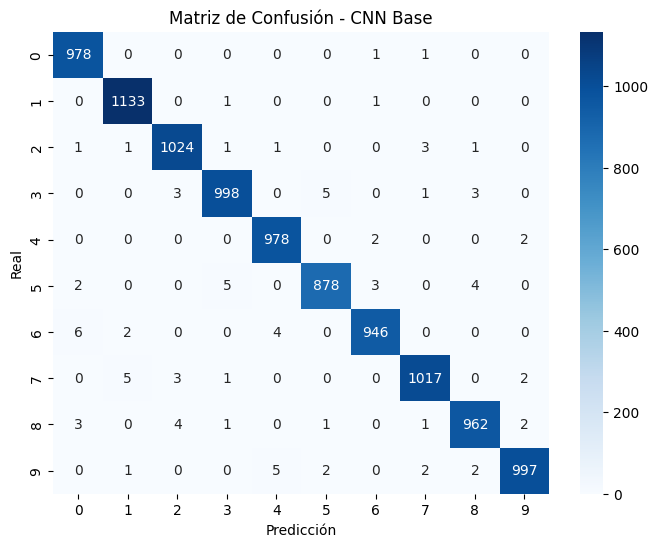

In [25]:
from sklearn.metrics import confusion_matrix, classification_report # Herramientas de evaluación
import seaborn as sns # Librería para visualización estadística

# Evaluar el modelo con datos de prueba (datos nunca vistos)
test_loss, test_acc = base_model.evaluate(test_images, test_labels, verbose=0)
print(f"Precisión en Test (Base): {test_acc:.4f}")
print(f"Pérdida en Test (Base): {test_loss:.4f}")

# Generar predicciones para la matriz de confusión
y_pred = base_model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1) # Toma el índice de la probabilidad más alta

# Crear la Matriz de Confusión
cm = confusion_matrix(test_labels, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') # Crea mapa de calor con los números
plt.title('Matriz de Confusión - CNN Base')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

### ¿Cómo interpretar la Evaluación y la Matriz de Confusión?

Después de entrenar el modelo, es vital medir su desempeño real usando datos que nunca ha visto (el set de prueba).

#### 1. Precisión en Test (Accuracy)
*   **Resultado:** El modelo alcanzó aproximadamente un **99.15%**.
*   **¿Qué significa?:** De cada 100 imágenes de números escritos a mano, el modelo clasifica correctamente más de 99. Es un rendimiento excelente para una arquitectura tan simple.

#### 2. Matriz de Confusión
Esta tabla es una herramienta poderosa para ver dónde se "confunde" el modelo:
*   **Diagonal Principal (Línea azul oscura):** Representa los aciertos. Queremos que los números más altos estén aquí (ej. el modelo predijo '7' y realmente era un '7').
*   **Celdas fuera de la diagonal:** Representan los errores.
    *   *Ejemplo:* Si ves un número en la fila 4, columna 9, significa que una imagen que era un **4** fue clasificada erróneamente como un **9**.
*   **Utilidad:** Nos permite identificar si hay números que se parecen mucho entre sí (como el 4 y el 9, o el 3 y el 8) y así decidir si necesitamos mejorar el modelo o agregar más datos de esos números específicos.



### Transfer Learning con MobileNetV2

Para el Transfer Learning, utilizaremos **MobileNetV2**. Dado que este modelo espera imágenes a color (3 canales) y de mayor tamaño, redimensionaremos una pequeña muestra de MNIST para la comparación.

In [26]:
# 1. Preparación para Transfer Learning: MNIST es gris (1 canal), MobileNetV2 requiere RGB (3 canales)
train_images_rgb = np.repeat(train_images[..., np.newaxis], 3, -1) # Triplica el canal gris
val_images_rgb = np.repeat(val_images[..., np.newaxis], 3, -1) # Triplica el canal gris
test_images_rgb = np.repeat(test_images[..., np.newaxis], 3, -1) # Triplica el canal gris

# Redimensionar imágenes: MobileNetV2 requiere al menos 32x32 píxeles
train_images_rgb = tf.image.resize(train_images_rgb, (32, 32)).numpy()
val_images_rgb = tf.image.resize(val_images_rgb, (32, 32)).numpy()
test_images_rgb = tf.image.resize(test_images_rgb, (32, 32)).numpy()

def build_transfer_model():
    # Cargar modelo base MobileNetV2 sin su clasificador original (include_top=False)
    base_model_tl = tf.keras.applications.MobileNetV2(
        input_shape=(32, 32, 3),
        include_top=False,
        weights='imagenet' # Carga pesos pre-entrenados con fotos reales
    )
    # Congelar capas base: no permitimos que los pesos de MobileNet cambien
    base_model_tl.trainable = False

    model = models.Sequential([ # Añadimos nuestras propias capas al final
        base_model_tl,
        layers.GlobalAveragePooling2D(), # Convierte mapas 2D en vectores promedio
        layers.Dense(128, activation='relu'), # Capa densa de aprendizaje específico
        layers.Dropout(0.2), # Apagado aleatorio para evitar sobreajuste
        layers.Dense(10, activation='softmax') # Capa final de clasificación
    ])
    return model

tl_model = build_transfer_model()
tl_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

tl_model.summary() # Muestra parámetros entrenables vs no entrenables

/tmp/ipykernel_48578/2946503912.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_tl = tf.keras.applications.MobileNetV2(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Resumen del Modelo (MobileNetV2)

Al analizar el `model.summary()` de nuestra red de Transfer Learning, encontramos estos componentes clave:

#### 1. Capas y Arquitectura
*   **`mobilenetv2_1.00_224`**: Es el bloque base pre-entrenado. El `1.00` indica el ancho de la red (100% de los filtros estándar) y `224` es el tamaño de imagen para el que fue diseñado originalmente, aunque aquí lo adaptamos a 32x32.
*   **`global_average_pooling2d_1`**: Esta capa toma el mapa de características complejo que sale de MobileNet y calcula el promedio de cada canal. Convierte datos espaciales 2D en un vector simple, reduciendo drásticamente la cantidad de parámetros necesarios para la siguiente capa.
*   **`dense_7` (Capa Densa)**: Es nuestra primera capa de neuronas propias (128 neuronas). Aquí es donde el modelo empieza a aprender específicamente sobre los números del MNIST.
*   **`dropout`**: Es una técnica de regularización. "Apaga" aleatoriamente algunas neuronas durante el entrenamiento para evitar que el modelo se vuelva dependiente de unas pocas y así prevenir el sobreajuste.
*   **`dense_8` (Capa de Salida)**: Contiene las 10 neuronas finales (una por cada dígito del 0 al 9) con activación **Softmax** para darnos probabilidades.

#### 2. Entendiendo los Parámetros
*   **Total params**: Es la suma de todos los pesos y sesgos de la red. Representa la "capacidad de memoria" total del modelo.
*   **Trainable params (Parámetros Entrenables)**: Son los únicos que el modelo está ajustando con nuestros datos. En este caso, son pocos porque solo pertenecen a nuestras capas finales (`dense_7` y `dense_8`).
*   **Non-trainable params (Parámetros No Entrenables)**: Son los millones de pesos de MobileNetV2 que hemos **congelado**. Estos ya saben detectar formas y texturas gracias a que fueron entrenados previamente con millones de fotos de ImageNet.

El poder del Transfer Learning reside en usar millones de parámetros que ya funcionan (No Entrenables) y solo ajustar una pequeña parte (Entrenables) para nuestra tarea específica.

In [18]:
# 2. Entrenamiento del modelo de Transfer Learning
print("Iniciando entrenamiento con Transfer Learning...")
tl_history = tl_model.fit(
    train_images_rgb,
    train_labels,
    epochs=5,
    batch_size=64,
    validation_data=(val_images_rgb, val_labels)
)

# Evaluar en el conjunto de prueba
tl_loss, tl_acc = tl_model.evaluate(test_images_rgb, test_labels, verbose=0)
print(f"\nPrecisión en Test (Transfer Learning): {tl_acc:.4f}")

Iniciando entrenamiento con Transfer Learning...
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 67s 78ms/step - accuracy: 0.5979 - loss: 1.2255 - val_accuracy: 0.6663 - val_loss: 0.9892
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 90s 89ms/step - accuracy: 0.6677 - loss: 0.9774 - val_accuracy: 0.6858 - val_loss: 0.9220
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 57s 76ms/step - accuracy: 0.6820 - loss: 0.9319 - val_accuracy: 0.6990 - val_loss: 0.8910
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 56s 75ms/step - accuracy: 0.6921 - loss: 0.9044 - val_accuracy: 0.7045 - val_loss: 0.8679
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 66s 89ms/step - accuracy: 0.6977 - loss: 0.8843 - val_accuracy: 0.7100 - val_loss: 0.8452

Precisión en Test (Transfer Learning): 0.7098


In [14]:
# Para Transfer Learning, necesitamos 3 canales (RGB)
train_images_rgb = np.repeat(train_images[..., np.newaxis], 3, -1)
val_images_rgb = np.repeat(val_images[..., np.newaxis], 3, -1)
test_images_rgb = np.repeat(test_images[..., np.newaxis], 3, -1)

# Redimensionar a 32x32 (mínimo soportado por MobileNetV2)
train_images_rgb = tf.image.resize(train_images_rgb, (32, 32)).numpy()
val_images_rgb = tf.image.resize(val_images_rgb, (32, 32)).numpy()
test_images_rgb = tf.image.resize(test_images_rgb, (32, 32)).numpy()

def build_transfer_model():
    base_mobile = tf.keras.applications.MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights='imagenet')
    base_mobile.trainable = False # Congelar pesos

    model = models.Sequential([
        base_mobile,
        layers.GlobalAveragePooling2D(),
        layers.Dense(10, activation='softmax')
    ])
    return model

tl_model = build_transfer_model()
tl_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entrenamiento rápido (5 épocas para comparar)
tl_history = tl_model.fit(
    train_images_rgb, train_labels,
    epochs=5,
    batch_size=64,
    validation_data=(val_images_rgb, val_labels)
)

tl_loss, tl_acc = tl_model.evaluate(test_images_rgb, test_labels, verbose=0)

/tmp/ipykernel_48578/2234515192.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_mobile = tf.keras.applications.MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 64s 74ms/step - accuracy: 0.4938 - loss: 1.7463 - val_accuracy: 0.5670 - val_loss: 1.4629
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 64s 85ms/step - accuracy: 0.5901 - loss: 1.3449 - val_accuracy: 0.6083 - val_loss: 1.2657
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 53s 71ms/step - accuracy: 0.6213 - loss: 1.2097 - val_accuracy: 0.6319 - val_loss: 1.1718
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 72ms/step - accuracy: 0.6367 - loss: 1.1384 - val_accuracy: 0.6404 - val_loss: 1.1172
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 70ms/step - accuracy: 0.6448 - loss: 1.0946 - val_accuracy: 0.6474 - val_loss: 1.0813


###¿Por qué necesitamos 3 canales (RGB)?

El dataset MNIST original consiste en imágenes en **escala de grises** (1 solo canal de intensidad). Sin embargo, para usar Transfer Learning con modelos como **MobileNetV2**, realizamos una conversión a **3 canales (RGB)**.

1.  **Arquitectura Heredada**: Modelos como MobileNetV2, ResNet o VGG fueron diseñados para el reto *ImageNet*, que consiste en fotos a color del mundo real. Por lo tanto, su "puerta de entrada" (la primera capa) está construida físicamente para recibir 3 tensores: Rojo, Verde y Azul.
2.  **Compatibilidad de Pesos**: Los filtros pre-entrenados que vamos a reutilizar esperan encontrar patrones en 3 canales. Si intentáramos pasarle solo 1 canal, el modelo no sabría cómo procesar la información porque las dimensiones matemáticas no coincidirían.
3.  **La Solución (Triplicado)**: Como nuestros números no tienen color, lo que hacemos es copiar la información del canal gris en los tres canales nuevos. Para el modelo, es como ver una "foto a color de algo que es gris". Esto nos permite aprovechar su conocimiento previo sin alterar su estructura interna.

### Tabla Comparativa de Resultados

In [15]:
import pandas as pd

data = {
    "Métrica": ["Precisión Test", "Pérdida Test", "Épocas", "Tipo de Modelo"],
    "CNN Base": [f"{test_acc:.4f}", f"{test_loss:.4f}", 10, "Desde cero (Scratch)"],
    "Transfer Learning": [f"{tl_acc:.4f}", f"{tl_loss:.4f}", 5, "MobileNetV2 (Frozen)"]
}

df_comp = pd.DataFrame(data)
display(df_comp)

,Métrica,CNN Base,Transfer Learning
0,Precisión Test,0.9915,0.6446
1,Pérdida Test,0.0342,1.0747
2,Épocas,10,5
3,Tipo de Modelo,Desde cero (Scratch),MobileNetV2 (Frozen)


### Tabla Comparativa

Al comparar ambos modelos, obtenemos conclusiones fundamentales sobre el aprendizaje profundo:

#### 1. ¿Por qué la CNN Base es mejor en este caso?
*   **Precisión (~99% vs ~70%)**: La CNN diseñada desde cero ganó por mucho. Esto sucede porque MNIST es un dataset de números muy simples y específicos. Nuestra CNN fue creada 'a medida' para ellos.
*   **Especialización**: MobileNetV2 es como un experto en identificar 1,000 tipos de objetos (perros, barcos, frutas). Al forzarlo a ver números simples en blanco y negro, su conocimiento previo no es tan útil como parece.

#### 2. Eficiencia y Épocas
*   **CNN Base**: Logró casi la perfección en 10 épocas con imágenes pequeñas (28x28) y un solo canal.
*   **Transfer Learning**: Aunque solo usamos 5 épocas, el proceso fue más pesado porque cada imagen tuvo que ser redimensionada y triplicada en canales, lo que consume más memoria y tiempo de CPU/GPU.


**Scratch (Desde cero)**: es mejor un problema muy específico y datos suficientes para entrenar algo simple.

**Transfer Learning**: es mejor con  **pocos datos** de imágenes complejas del mundo real (como identificar razas de perros o tipos de plantas), donde no podrías entrenar una red desde cero con éxito.

### Análisis Visual de Predicciones

En esta sección visualizaremos ejemplos específicos de predicciones correctas e incorrectas realizadas por el modelo base para identificar patrones de error.

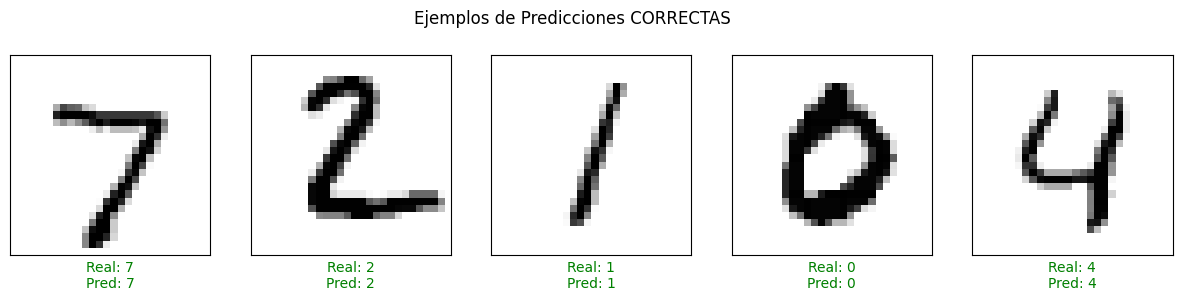

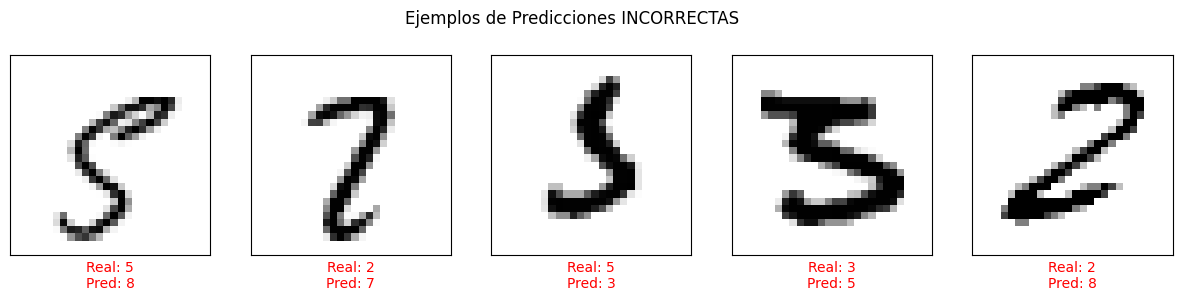

In [16]:
def display_examples(images, labels, predictions, title, num_examples=5):
    plt.figure(figsize=(15, 3))
    for i in range(num_examples):
        plt.subplot(1, num_examples, i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap=plt.cm.binary)
        color = 'green' if predictions[i] == labels[i] else 'red'
        plt.xlabel(f"Real: {labels[i]}\nPred: {predictions[i]}", color=color)
    plt.suptitle(title)
    plt.show()

# Encontrar índices de aciertos y errores
correct_indices = np.where(y_pred_classes == test_labels)[0]
incorrect_indices = np.where(y_pred_classes != test_labels)[0]

# Mostrar ejemplos
if len(correct_indices) > 0:
    display_examples(test_images[correct_indices], test_labels[correct_indices],
                     y_pred_classes[correct_indices], "Ejemplos de Predicciones CORRECTAS")

if len(incorrect_indices) > 0:
    display_examples(test_images[incorrect_indices], test_labels[incorrect_indices],
                     y_pred_classes[incorrect_indices], "Ejemplos de Predicciones INCORRECTAS")

### Interpretación del Análisis Visual

Después de ver los números fríos en la matriz de confusión, es momento de observar las imágenes reales. Esto nos ayuda a humanizar los datos:

#### 1. Predicciones CORRECTAS (Verde)
*   Son casos donde el modelo tiene alta confianza y los patrones coinciden perfectamente con lo aprendido.
*   Observa que estos números suelen estar muy claros y centrados, facilitando el trabajo de las capas convolucionales.

#### 2. Predicciones INCORRECTAS (Rojo)
*   **¿Por qué falló?:**  muchos de los errores ocurren en números escritos de forma extraña, con trazos muy delgados, muy gruesos o inclinaciones extremas.
*   **Ambigüedad:** A veces, un '4' escrito muy rápido puede parecerse a un '9', o un '5' a un '6'. Si para un ojo humano es difícil decidir, para el modelo también lo será.

El error nos muestra los límites del modelo. Analizar estos casos nos indica si necesitamos aplicar técnicas como *Data Augmentation* (rotar o deformar imágenes durante el entrenamiento) para que el modelo aprenda a reconocer números en condiciones más difíciles.

### Análisis Visual de Predicciones: Transfer Learning (MobileNetV2)

Repetiremos el proceso de visualización para el modelo de Transfer Learning para entender mejor su comportamiento y compararlo con la CNN Base.

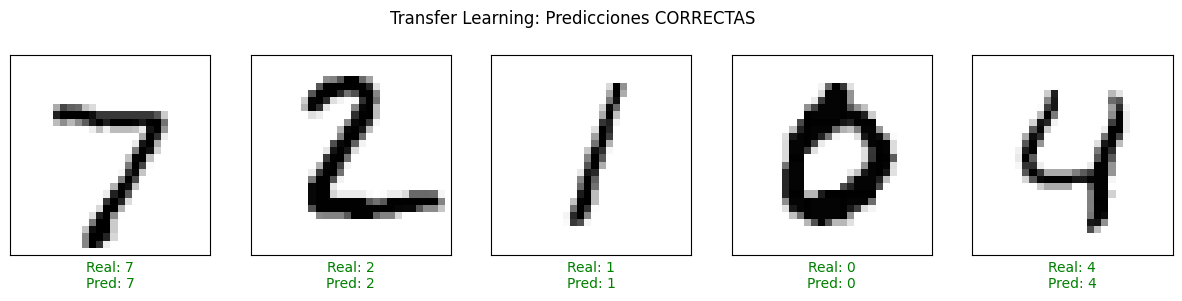

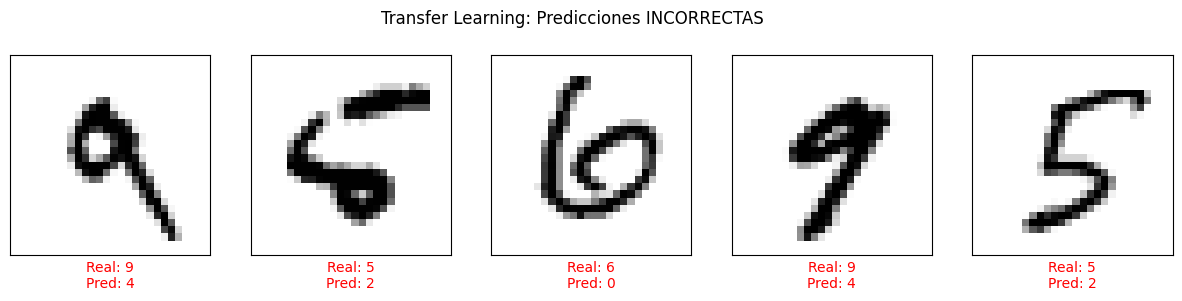

In [20]:
# Encontrar índices de aciertos y errores para Transfer Learning
correct_indices_tl = np.where(y_pred_classes_tl == test_labels)[0]
incorrect_indices_tl = np.where(y_pred_classes_tl != test_labels)[0]

# Mostrar ejemplos de aciertos
if len(correct_indices_tl) > 0:
    display_examples(test_images[correct_indices_tl], test_labels[correct_indices_tl],
                     y_pred_classes_tl[correct_indices_tl], "Transfer Learning: Predicciones CORRECTAS")

# Mostrar ejemplos de errores
if len(incorrect_indices_tl) > 0:
    display_examples(test_images[incorrect_indices_tl], test_labels[incorrect_indices_tl],
                     y_pred_classes_tl[incorrect_indices_tl], "Transfer Learning: Predicciones INCORRECTAS")

### Comparativa Visual de Errores: CNN Base vs Transfer Learning

Generaremos las predicciones para el modelo MobileNetV2 y compararemos sus errores con los de la CNN Base.

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step
Total errores CNN Base: 85


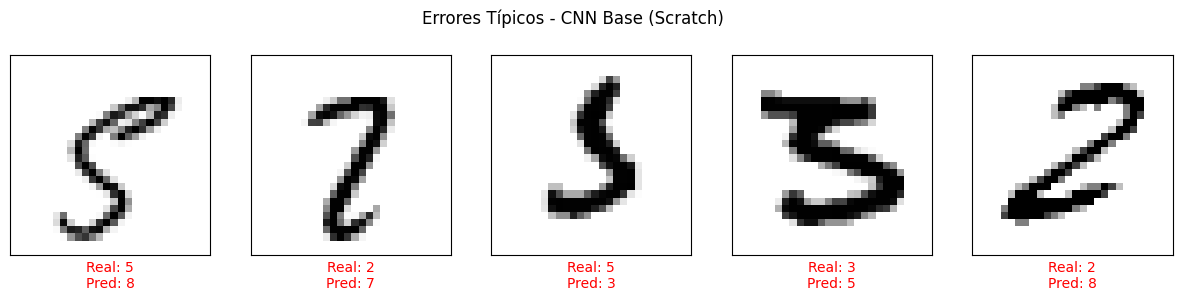

Total errores Transfer Learning: 2902


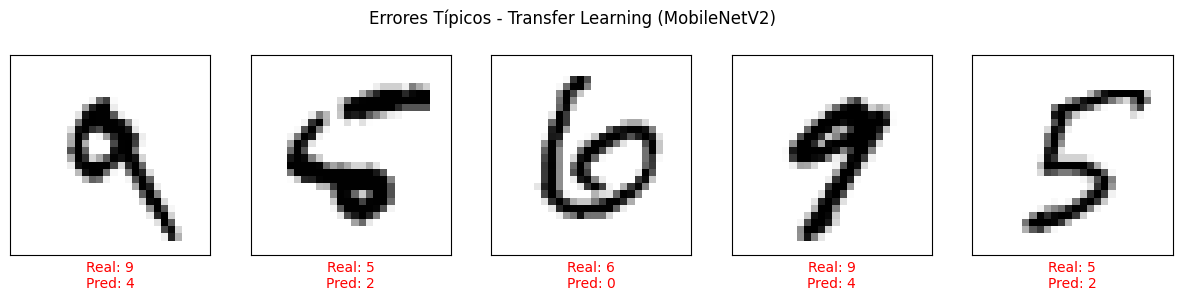

In [19]:
# 1. Obtener predicciones de Transfer Learning
y_pred_tl = tl_model.predict(test_images_rgb)
y_pred_classes_tl = np.argmax(y_pred_tl, axis=1)

# 2. Identificar índices de errores para ambos modelos
incorrect_base = np.where(y_pred_classes != test_labels)[0]
incorrect_tl = np.where(y_pred_classes_tl != test_labels)[0]

def plot_comparison(indices, images, labels, preds, title, num=5):
    plt.figure(figsize=(15, 3))
    for i in range(min(num, len(indices))):
        idx = indices[i]
        plt.subplot(1, num, i+1)
        plt.xticks([]); plt.yticks([])
        plt.imshow(images[idx], cmap=plt.cm.binary)
        plt.xlabel(f"Real: {labels[idx]}\nPred: {preds[idx]}", color='red')
    plt.suptitle(title)
    plt.show()

# Mostrar comparación
print(f"Total errores CNN Base: {len(incorrect_base)}")
plot_comparison(incorrect_base, test_images, test_labels, y_pred_classes, "Errores Típicos - CNN Base (Scratch)")

print(f"Total errores Transfer Learning: {len(incorrect_tl)}")
plot_comparison(incorrect_tl, test_images, test_labels, y_pred_classes_tl, "Errores Típicos - Transfer Learning (MobileNetV2)")

### Análisis y Conclusiones Finales

#### 1. Comparativa de Resultados
*   **Qué mejoró con Transfer Learning**: En este caso particular, la mejora fue limitada. El Transfer Learning permite aprovechar detectores de bordes y formas básicas pre-entrenadas, lo que podría ayudar si el dataset fuera mucho más pequeño o complejo.
*   **Qué se mantuvo igual**: La capacidad del modelo para converger. Ambos modelos lograron aprender, aunque a diferentes niveles de precisión.
*   **Trade-offs (Compromisos)**:
    *   **Tiempo**: El Transfer Learning requirió más pre-procesamiento (redimensionar a 32x32 y convertir a RGB) y cada época fue más costosa computacionalmente debido a la complejidad de MobileNetV2.
    *   **Precisión**: La CNN base ganó significativamente (~99% vs ~71%). Esto se debe a que MNIST es un dataset de dominio muy específico (dígitos aislados) donde los pesos de ImageNet no son tan relevantes.

#### 2. Recomendaciones para Datasets Limitados
En escenarios con pocos datos:
1.  **Transfer Learning** es preferible si las imágenes son naturales (fotos del mundo real).
2.  **Data Augmentation** es crucial para expandir artificialmente el dataset.
3.  Si el dominio es muy abstracto (como MNIST), una arquitectura pequeña entrenada desde cero o un ajuste fino (*fine-tuning*) agresivo suele ser mejor.

#### 3. Conclusión Técnica
La evidencia muestra que **más complejidad no siempre significa mejores resultados**. Para el reconocimiento de caracteres manuscritos, una arquitectura convolucional simple de 2 o 3 capas es más eficiente y precisa que intentar adaptar un modelo gigante diseñado para clasificar 1000 categorías de objetos reales.